Importing dependencies and loading data

In [13]:
import pandas as pd
import talib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid") 

# --- REUSABLE FUNCTION DEFINITION ---

def analyze_stock(ticker, filename):
    """
    Loads stock data, calculates technical indicators, 
    and generates plots for a given stock.
    """
    print(f"--- Starting Analysis for {ticker} ---")
    
    # 1. LOAD, CLEAN, AND INDEX (Using the fixed path)
    df = pd.read_csv(f'../data/{filename}') 
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    
    if 'Adj Close' in df.columns:
        df.drop('Adj Close', axis=1, inplace=True)
        
    df.dropna(inplace=True) 

    # 2. CALCULATE INDICATORS
    df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
    df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)
    df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(
        df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
    )
    
    # 3. VISUALIZE

    # SMA Plot
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['Close'], label='Close Price', color='blue', alpha=0.6)
    plt.plot(df.index, df['SMA_20'], label='20-Day SMA', color='red')
    plt.title(f'{ticker} Closing Price and 20-Day Moving Average')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{ticker.lower()}_sma_plot.png')
    plt.close() # Use plt.close() to prevent showing the plot interactively in some environments

    # RSI Plot
    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
    plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
    plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
    plt.title(f'{ticker} Relative Strength Index (RSI)')
    plt.legend()
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.savefig(f'{ticker.lower()}_rsi_plot.png')
    plt.close()

    # MACD Plot
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax1.plot(df.index, df['MACD'], label='MACD Line', color='blue')
    ax1.plot(df.index, df['MACD_Signal'], label='Signal Line', color='orange')
    ax2 = ax1.twinx()
    ax2.bar(df.index, df['MACD_Hist'], label='Histogram', color='grey', alpha=0.3)
    ax1.set_title(f'{ticker} MACD Indicator')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{ticker.lower()}_macd_plot.png')
    plt.close()
    
    print(f"--- Analysis Complete for {ticker} ---\n")
    return df

Standardize Columns : Ensuring the columns are standardized for TA_Lib

In [5]:
# The yfinance columns are usually correct: Open, High, Low, Close, Volume.
# You might want to drop the 'Adj Close' column if you only use 'Close' for analysis
if 'Adj Close' in df_aapl.columns:
    df_aapl.drop('Adj Close', axis=1, inplace=True)

# Check for missing values (TA-Lib cannot handle NaNs)
print("\nMissing values before cleaning:")
print(df_aapl.isnull().sum())

# Simple fix: drop rows with any missing values
df_aapl.dropna(inplace=True) 

print(f"\nCleaned data: {len(df_aapl)} rows remain.")
print(df_aapl.head())


Missing values before cleaning:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Cleaned data: 3774 rows remain.
         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


Calculate basic technical indicators: calculating moving averages, relative strength index and moving average convergence divergence

In [14]:
# --- FUNCTION CALLS ---

# 1. AAPL
df_aapl_final = analyze_stock("AAPL", "AAPL.csv")

# 2. AMZN
df_amzn_final = analyze_stock("AMZN", "AMZN.csv")

#3. GOOG
df_goog_final = analyze_stock("GOOG","GOOG.csv")
#4. META
df_meta_final = analyze_stock("META","META.csv")
#5. MSFT
df_msft_final = analyze_stock("MSFT","MSFT.csv")
#6. NVDA
df_nvda_final = analyze_stock("NVDA","NVDA.csv")

# 3. Remaining stocks (if you have the files, e.g., 'GOOGL.csv')
# df_gogl_final = analyze_stock("GOOGL", "GOOGL.csv") 
# ... and so on

--- Starting Analysis for AAPL ---
--- Analysis Complete for AAPL ---

--- Starting Analysis for AMZN ---
--- Analysis Complete for AMZN ---

--- Starting Analysis for GOOG ---
--- Analysis Complete for GOOG ---

--- Starting Analysis for META ---
--- Analysis Complete for META ---

--- Starting Analysis for MSFT ---
--- Analysis Complete for MSFT ---

--- Starting Analysis for NVDA ---
--- Analysis Complete for NVDA ---



In [7]:
# Calculate 14-day RSI (standard setting)
df_aapl['RSI_14'] = talib.RSI(df_aapl['Close'], timeperiod=14)
print("RSI calculated.")

RSI calculated.


In [8]:
# Calculate MACD, MACD Signal Line, and MACD Histogram
df_aapl['MACD'], df_aapl['MACD_Signal'], df_aapl['MACD_Hist'] = talib.MACD(
    df_aapl['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)
print("MACD calculated.")

print("\nFinal DataFrame with Indicators:")
print(df_aapl.tail())


MACD calculated.

Final DataFrame with Indicators:
            Date       Close        High         Low        Open    Volume  \
3769  2023-12-22  191.788757  193.581821  191.164647  193.353962  37149600   
3770  2023-12-26  191.243912  192.076049  191.025969  191.798670  28919300   
3771  2023-12-27  191.342972  191.689703  189.302247  190.689158  48087700   
3772  2023-12-28  191.768951  192.838849  191.362784  192.323710  34049900   
3773  2023-12-29  190.728775  192.581275  189.936256  192.085953  42672100   

          SMA_20     RSI_14      MACD  MACD_Signal  MACD_Hist  
3769  191.856618  54.672784  2.633141     3.235256  -0.602115  
3770  192.018094  53.090049  2.304751     3.049155  -0.744404  
3771  192.154308  53.354446  2.029104     2.845145  -0.816041  
3772  192.362839  54.540999  1.823998     2.640915  -0.816918  
3773  192.490633  51.121347  1.559539     2.424640  -0.865101  


Visualizing the data: price and Moving average plot

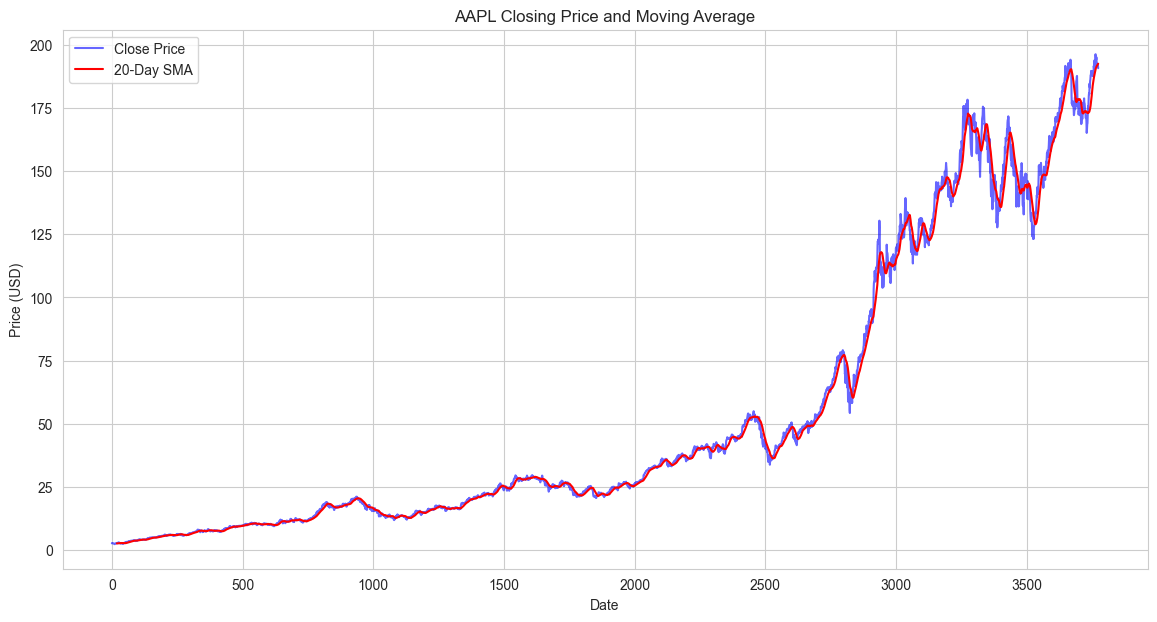

In [10]:
ticker_symbol = "AAPL"
plt.figure(figsize=(14, 7))

# Plot the Closing Price
plt.plot(df_aapl.index, df_aapl['Close'], label='Close Price', color='blue', alpha=0.6)

# Plot the 20-day Simple Moving Average (SMA)
plt.plot(df_aapl.index, df_aapl['SMA_20'], label='20-Day SMA', color='red')

plt.title(f'{ticker_symbol} Closing Price and Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

RSI PLOT

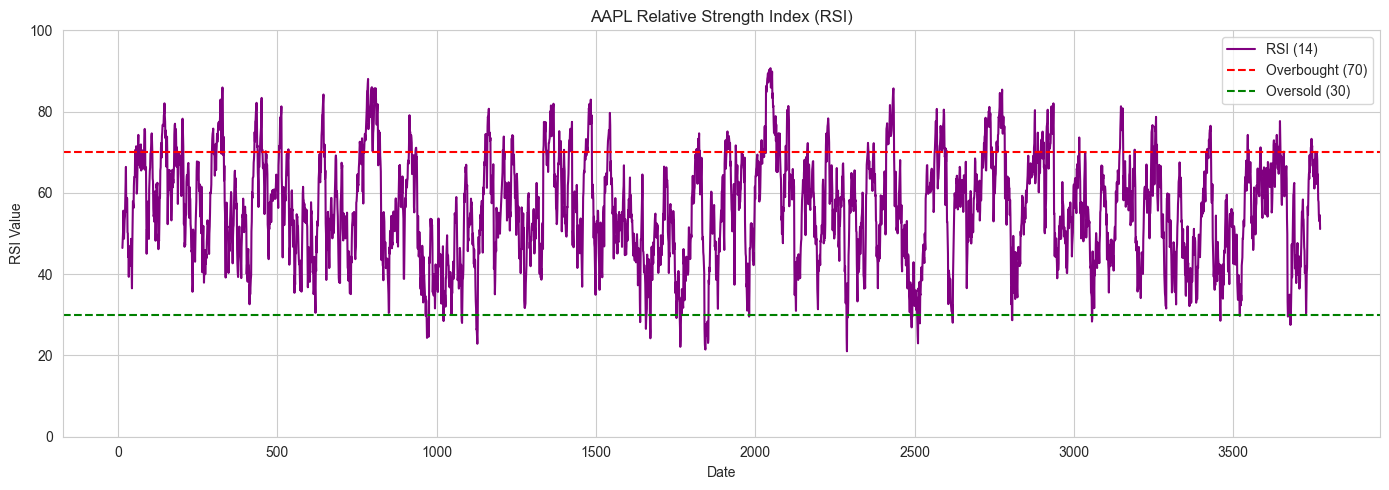

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df_aapl.index, df_aapl['RSI_14'], label='RSI (14)', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('AAPL Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('aapl_rsi_plot.png') # Save the plot as a file
plt.show()

MACD PLOT

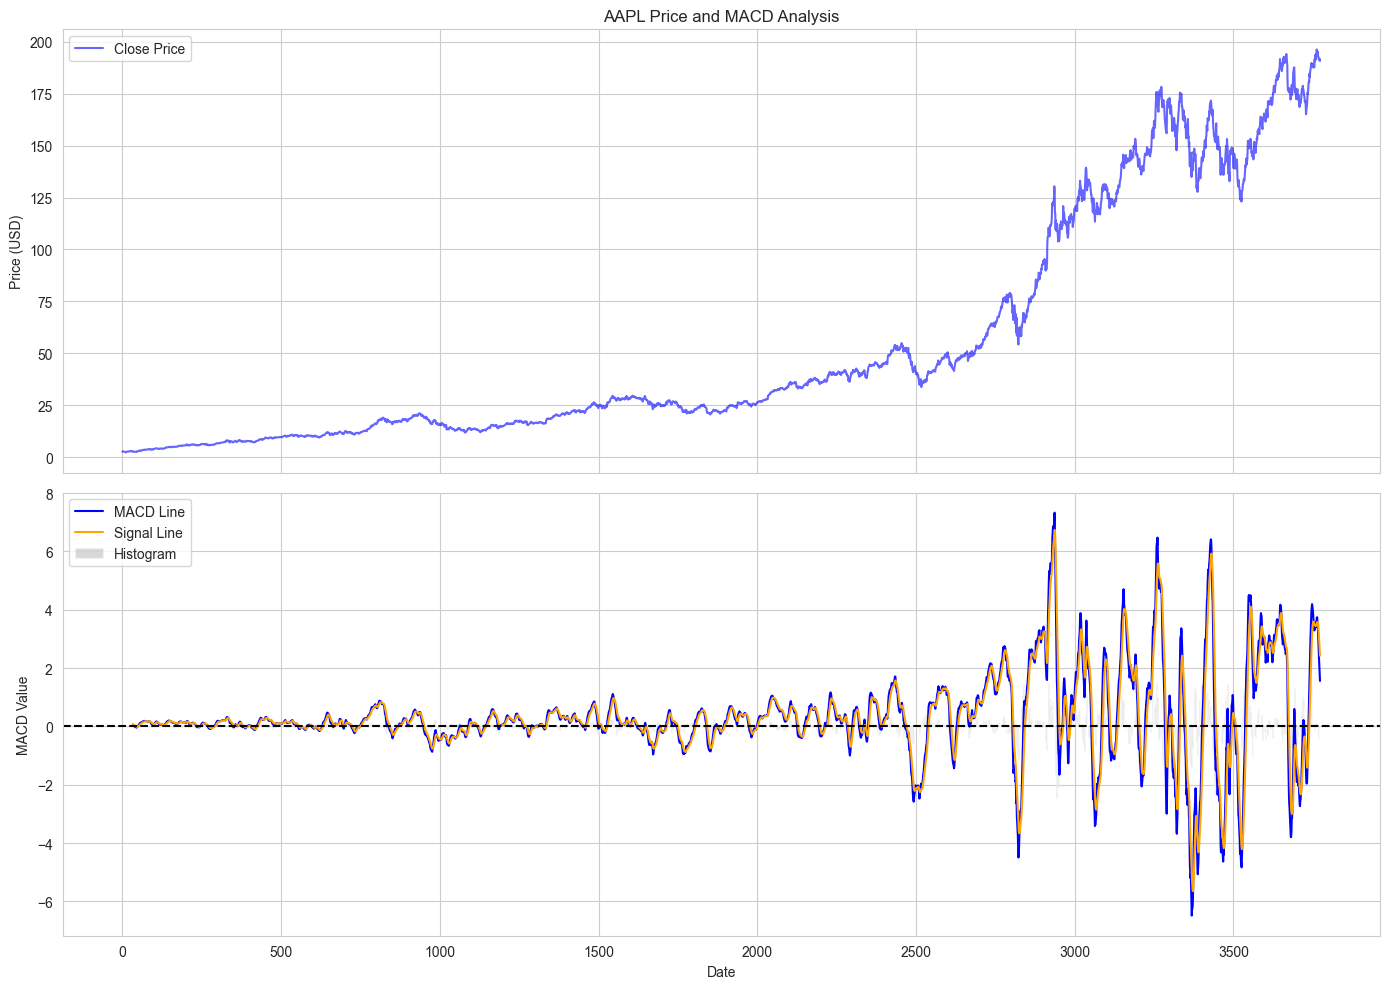

In [12]:
# MACD plots typically use two panels: price in the top, and MACD components in the bottom
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Panel: Price (Optional but helpful)
ax1.plot(df_aapl.index, df_aapl['Close'], label='Close Price', color='blue', alpha=0.6)
ax1.set_title('AAPL Price and MACD Analysis')
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')

# Bottom Panel: MACD Components
ax2.plot(df_aapl.index, df_aapl['MACD'], label='MACD Line', color='blue')
ax2.plot(df_aapl.index, df_aapl['MACD_Signal'], label='Signal Line', color='orange')
ax2.bar(df_aapl.index, df_aapl['MACD_Hist'], label='Histogram', color='grey', alpha=0.3)
ax2.axhline(0, color='black', linestyle='--') # Zero line
ax2.set_xlabel('Date')
ax2.set_ylabel('MACD Value')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('aapl_macd_plot.png') # Save the plot as a file
plt.show()